# Case study: Modelling real-world Influenza activity.
This notebook presents a case study for modelling the real-world activity of Influenza in the United States. We use the ICL NREVSS dataset for this purpose, which is publicly available at https://gis.cdc.gov/grasp/fluview/fluportaldashboard.html.

This notebook consists of three parts,
1. Data exploration
2. Data preprocessing
3. Parameter calibration with a finite-state mean field game susceptible-infected-recovered (SIR) model,

and reflects the experimental setup used in `experiments/SIR/nrevss.py`.

**Data and license information** <br>
The data, as retrieved from the FluView dashboard, falls under the U.S. public domain. The dataset that is featured in the paper has been retrieved on May 4, 2026. To exactly reproduce our results, you can filter any datasets that have been downloaded later by date.

In [1]:
# imports
import os
from typing import Tuple, Any, List, Dict

import numpy as np
import pandas as pd

import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm

from core.ParameterNetwork import ParameterNetwork
from core.PicardSolver import PicardSolver
from mean_field_games.SIR import SIR
from calibration.BaseTrainer import BaseTrainer
from data.ICL_NREVSS import get_ICL_NREVSS_data_from_path
from src.calibration.TrainingConfig import TrainingConfig
from src.data.ICL_NREVSS import get_custom_period, find_epidemic_onset, realign_curve, date_generator

## Loading the dataset
We are using the ``ICL_NREVSS_Clinical_Labs`` dataset, which includes weekly percentage of positive Influenza (A and B) tests, grouped by the states of America. This dataset contains missing values, which are represented by an `'X'`. We interpolate the missing values where possible.

**SIR with missing data**<br>
Doing so, we focus on the percentage of positive Influenza A tests. Here, we treat the percentage of positive tests as $\mu(I)$, the fraction of the population $\mu$ that is infected. As we do not have any information about the total number of susceptible agents, or the recoveries we only learn the viral dynamics from the rising and trailing edge of the infection peak.

In [2]:
data_path = r"../data/ICL_NREVSS_Clinical_Labs.csv"
df = pd.read_csv(data_path)
df.head()

,REGION TYPE,REGION,YEAR,WEEK,TOTAL SPECIMENS,TOTAL A,TOTAL B,PERCENT POSITIVE,PERCENT A,PERCENT B
0,States,Alabama,2015,40,167,2,3,2.99,1.2,1.8
1,States,Alaska,2015,40,X,X,X,X,X,X
2,States,Arizona,2015,40,55,0,0,0,0,0
3,States,Arkansas,2015,40,26,0,1,3.85,0,3.85
4,States,California,2015,40,683,2,0,0.29,0.29,0


In [3]:
# First we interpolate the missing values within the column that describes the percentage
# of positive Influenza A tests.
df.replace("X", np.nan, inplace=True)
df["PERCENT A"] = df["PERCENT A"].astype(float).interpolate()
df_filled = df.copy()
df_filled.head()

,REGION TYPE,REGION,YEAR,WEEK,TOTAL SPECIMENS,TOTAL A,TOTAL B,PERCENT POSITIVE,PERCENT A,PERCENT B
0,States,Alabama,2015,40,167,2,3,2.99,1.20,1.8
1,States,Alaska,2015,40,NaN,NaN,NaN,NaN,0.60,NaN
2,States,Arizona,2015,40,55,0,0,0,0.00,0
3,States,Arkansas,2015,40,26,0,1,3.85,0.00,3.85
4,States,California,2015,40,683,2,0,0.29,0.29,0


### Visualising the Influenza A infections
We visualize the Influenza A infections of 5 pseudorandom (we just selected the first 5 states on alphabetical order) states below. The infections are pretty state and season specific: to provide an example, there seems to have been a high prevalence of Influenza A in California for the Season 2024-2025. At the same time, there aren't many positive tests recorded in Alaska.


In [4]:
def plot_infected(df: pd.DataFrame, fig: plt.Figure, ax: plt.Axes, color: Any) -> Tuple[plt.Figure, plt.Axes]:
    """
    Plot 'PERCENT A' over time from a DataFrame with 'YEAR' and 'WEEK' columns.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns: 'YEAR' (int), 'WEEK' (int), 'PERCENT A' (numeric).
    fig : plt.Figure
        The Figure to plot on.
    ax : plt.Axes
        The axes of the figure.
    color : Any
        The color of the plot.

    Returns
    -------
    fig : plt.Figure
        The matplotlib Figure object (so you can save or further customise it).
    """
    df = df.copy()

    df["date"] = pd.to_datetime(
        df["YEAR"].astype(str) + df["WEEK"].astype(str) + "1",
        format="%Y%W%w",
    )
    df = df.sort_values("date")

    ax.plot(
        df["date"],
        df["PERCENT A"].to_numpy(dtype=float) / 100,
        linewidth=1.6,
        color=color,
        label=df["REGION"].iloc[0],
        marker="o",
        markersize=3,
    )

    return fig, ax


def visualise_infections(df: pd.DataFrame, n_states: int = 5):
    fig, ax = plt.subplots(figsize=(14, 7))
    shades = cm.Blues(np.linspace(0.1, 1, n_states))

    for region, shade in zip(df["REGION"].unique()[:n_states], shades):
        # Filter a few years for readability
        df_filter = df[(df["REGION"] == region) & (df["YEAR"] > 2022) & (df["YEAR"] < 2026)]
        fig, ax, plot_infected(df_filter, fig, ax, shade)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    ax.xaxis.set_minor_formatter(mdates.DateFormatter("%b"))

    # Rotate minor (month) labels so they don't overlap
    for label in ax.xaxis.get_minorticklabels():
        label.set_fontsize(7)
        label.set_rotation(45)
        label.set_ha("right")

    for label in ax.xaxis.get_majorticklabels():
        label.set_fontsize(10)
        label.set_fontweight("bold")

    ax.set_xlabel("Date ($t$)", labelpad=8)
    ax.set_ylabel("Reported Influenza A cases ($\mu(I)_t$)")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.grid(axis="x", which="major", linestyle="-", alpha=0.3)
    ax.tick_params(axis="x", which="major", pad=18)

    fig.tight_layout()
    plt.show()

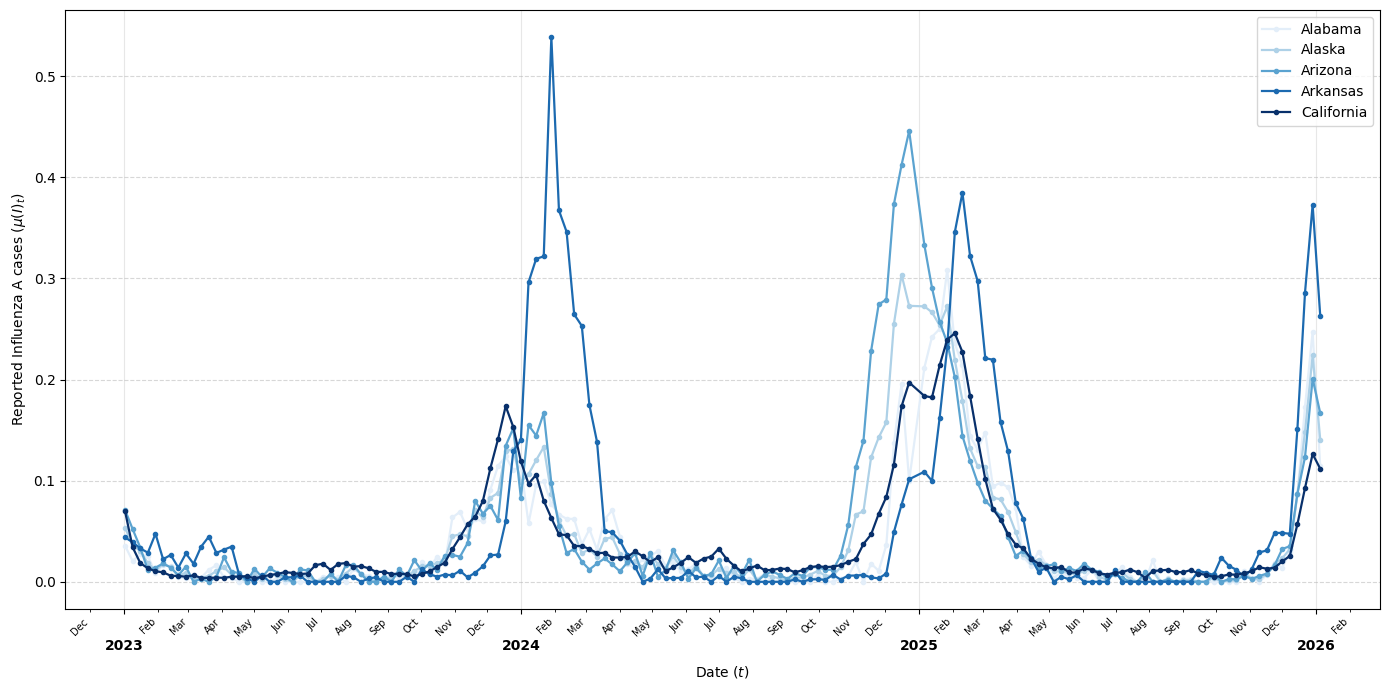

In [5]:
visualise_infections(df)

## Data preprocessing: splitting the data into seasons
Before we continue, we split the time series data, currently ranging from 2015-2026, into seasons; isolating the epidemic peaks. We do this for two reasons:
1. By splitting the data into seasons, we simply have more data to train and validate the model on.
2. Because we do not have any information about the Influenza A recoveries we cannot learn the dynamics that describe waning immunity (going from state $R$ to state $S$). Therefore, we only consider single flu seasons and assume that the immunity of all players persists within a single season (i.e., the rate of transitioning from $R \to S = 0$).

We provide the code for doing so below, but for our experiments, this utility is handled in `src/data/SIR/ICL_NREVSS.py`.

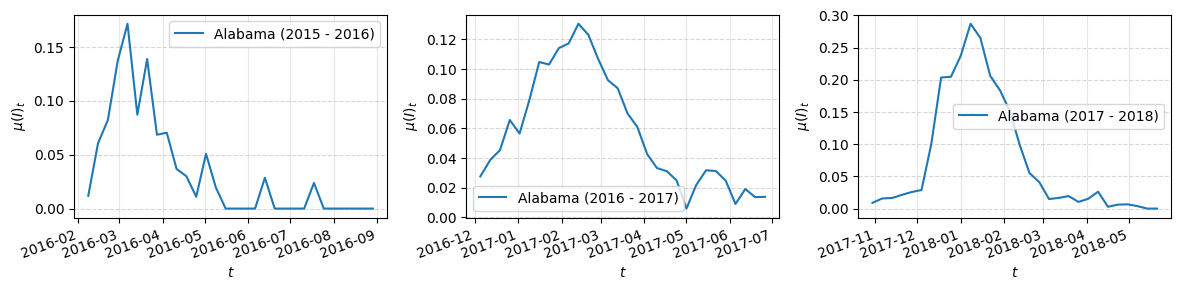

In [6]:
def split_seasons(_df: pd.DataFrame, t: int = 30):
    _df["date"] = pd.to_datetime(
        df["YEAR"].astype(str) + df["WEEK"].astype(str) + "1",
        format="%Y%W%w",
    )
    years = np.arange(2015, 2026, 1)

    state_list = []
    ts_list = []
    metadata = []

    for region in _df["REGION"].unique():
        for year in years:
            df_filter = _df[(_df["REGION"] == region)]
            df_filter = get_custom_period(df_filter, year)
            df_filter = df_filter.sort_values("date")

            df_filter.replace("X", np.nan, inplace=True)
            df_filter["PERCENT A"] = df_filter["PERCENT A"].astype(float).interpolate()

            df_filled = df_filter.copy()
            df_filled["PERCENT A"] = df_filled["PERCENT A"].astype(float).fillna(0)

            mu_infected = df_filled["PERCENT A"].to_numpy(dtype=float) / 100

            if len(mu_infected) > 0 and np.count_nonzero(mu_infected == 0) < mu_infected.shape[0] / 2:
                t_start = find_epidemic_onset(mu_infected)
                mu_aligned = realign_curve(mu_infected, t_start, T_out=t)

                state_list.append(mu_aligned)
                ts_list.append(np.arange(t))
                dates = np.array(list(date_generator(df_filled["date"].iloc[t_start], len(mu_aligned))))

                metadata.append([region, year, dates])


    mu_infected = np.column_stack(state_list).T
    mu_susceptible = np.ones_like(mu_infected)
    mu_recovered = np.zeros_like(mu_infected)

    mu = np.stack([mu_susceptible, mu_infected, mu_recovered], axis=-1)

    ts = np.column_stack(ts_list).T

    return ts, mu, metadata

ts, mu, metadata = split_seasons(df_filled)

n_plots = 3
fig, axes = plt.subplots(1, n_plots, figsize=(12, 3))

for i in range(n_plots):
    axes[i].plot(metadata[i][-1], mu[i, :, 1], label=f"{metadata[i][0]} ({metadata[i][1]} - {metadata[i][1]+1})")
    axes[i].legend()
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)
    axes[i].grid(axis="x", which="major", linestyle="-", alpha=0.3)
    axes[i].set_xticks(axes[i].get_xticks(), axes[i].get_xticklabels(), rotation=20, ha='right')
    axes[i].set_xlabel("$t$")
    axes[i].set_ylabel("$\mu(I)_t$")
plt.tight_layout()
plt.show()

**Remark**: The approach outlined above does not capture the infection peaks perfectly. Instead, each flu season is described by a different $\mu_0$. This is for a good reason: if we were to present the model with identical initial states, say  $\mu_0 = [1.0, 0.0, 0.0]$, and solve the initial value problem, we would never be able to learn and generalize over the disease dynamics. With our approximate split, we obtain a lot of different values for $\mu_0$, increasing the versatility of our input data in the train and test split.

## Parameter calibration
We use the SIR mean field game to model the data, where we actively learn the costs for being infected ($c_I$) and reducing the contact factor ($c_a$). Thus, including the rates describing the transitions from $S \to I$ and $I \to R$, we learn $|\gamma| = 4$ parameters.

We set the `OBSERVED_INDEX` to `[1]` to only calculate the loss w.r.t. the ratio of infected individuals, in addition, we train the network for 500 epochs.

We provide a modified version of the `NrevssTrainer` below that is more suited for notebooks.

In [7]:

OBSERVED_INDEX = [1]  # Only the infected compartment is observed

cfg = TrainingConfig(
    constant_gamma=False,
    is_mfc=False,
    # Network outputs SIR params + optional cost params
    gamma_size=4,
    gamma_loss_idx=0,
    num_seeds=1,
    epochs=500,
    # T, N, and num_samples are determined by the dataset, overridden in generate_data
    T=1,
    N=1,
    num_samples=1,
    num_test_samples=1,
    batch_size=2,
    learning_rate=1e-3,
    delta_ratio=0.2,
    test_interval=20,
    picard_damping=0.0,
    root_dir="./",
    experiment_name="notebook",
)


class NrevssTrainer(BaseTrainer):
    def __init__(self) -> None:
        self._mu_train, self._mu0_train, self._g_train, self._meta_train = get_ICL_NREVSS_data_from_path(
            data_path, train=True
        )
        self._mu_test, self._mu0_test, self._g_test, self._meta_test = get_ICL_NREVSS_data_from_path(
            data_path, train=False
        )

        # Patch config with real dataset sizes
        cfg.T = float(self._mu_train[0, -1, 0])
        cfg.N = self._mu_train.shape[1]
        cfg.num_samples = self._mu_train.shape[0]
        cfg.num_test_samples = self._mu_test.shape[0]

        super().__init__(cfg)

    def _build_mfg(self, d: int) -> Tuple:
        mfg = SIR(0, 0, learn_cost=True)
        picard = PicardSolver(mfg=mfg, dt=self.cfg.dt, is_mfc=self.cfg.is_mfc, damping=self.cfg.picard_damping)
        return mfg, picard.get_solver_fn()

    def generate_data(
        self, num: int, seed: int, noise_level: float, d: int, inject_concentrated: bool = False
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Return the cached real-world data (train or test based on *num*)."""
        if num == cfg.num_samples:
            return self._mu_train, self._mu0_train, self._g_train
        return self._mu_test, self._mu0_test, self._g_test

    def _build_loss_fn(self, model: ParameterNetwork, solver_fn: Any, d: int):
        def loss_fn(params, mu_o, mu0_o, s_idx):
            g_p = self._pred_g_traj(model, params, self.t_grid, mu_o)
            mu_p = solver_fn(g_p, None, jnp.repeat(mu0_o[None, :], self.cfg.N, axis=0), mu0_o)
            sl = lambda x: jax.lax.dynamic_slice(x, (s_idx, 0), (self.cfg.delta_steps, d))
            obs = lambda x: x[:, OBSERVED_INDEX]
            residual = jnp.mean(jnp.sum((obs(sl(mu_p)) - obs(sl(mu_o))) ** 2))
            return residual, (mu_p, g_p)

        return loss_fn

    def _build_full_eval(self, model: ParameterNetwork, solver_fn: Any):
        def full_eval(params, mo, m0):
            gp = self._pred_g_traj(model, params, self.t_grid, mo)
            mp = solver_fn(gp, None, jnp.repeat(m0[None, :], self.cfg.N, axis=0), m0)
            obs = lambda x: x[:, OBSERVED_INDEX]
            return jnp.mean(jnp.sum((obs(mp) - obs(mo)) ** 2)), mp, gp

        return full_eval

    def _get_checkpoint_path(self, folder: str, seed: int) -> str:
        return os.path.join(os.getcwd(), folder, f"best_checkpoint_seed_{seed}/")


    def _plot_results(
        self,
        cdir: str,
        results: List[Dict],
        t_grid: jnp.ndarray,
        te_epochs: jnp.ndarray,
    ) -> None:
        state = 0
        d = results[0]["mu_true"].shape[-1]

        results[0]['metadata'] = self._meta_test

        sir = ["S", "I", "R"]

        mu_true = np.array([seed["mu_true"] for seed in results])
        mu_pred = np.array([seed["mu_pred"] for seed in results])

        mean_pred = np.mean(mu_pred, axis=0)
        se_pred = np.std(mu_pred, axis=0) / len(results)


        year = results[0]["metadata"][state][1]
        if "metadata" in results[0].keys():
            x_axis = results[0]["metadata"][state][2]
            state_info = f" ({results[0]['metadata'][state][0]})"
        else:
            x_axis = t_grid
            state_info = ""

        fig, ax = plt.subplots(1, 1, figsize=(4, 3))

        ax.plot(
            x_axis,
            mu_true[0, state, :, 1],
            color="crimson",
            alpha=0.8,
            linewidth=1.5,
            linestyle="--",
            label=r"$\mu(I)$" + state_info,
        )
        for s in range(d):
            ax.plot(x_axis, mean_pred[state, :, s], color=f"C{s}", linewidth=1.5, label=rf"$\mu^\theta({sir[s]})$")
            ax.fill_between(
                x_axis,
                mean_pred[state, :, s] - se_pred[state, :, s],
                mean_pred[state, :, s] + se_pred[state, :, s],
                alpha=0.2,
                color=f"C{s}",
            )
        ax.set_ylabel(rf"$\mu$")

        if "metadata" in results[0].keys():
            ax.xaxis.set_major_locator(mdates.YearLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n(%Y)"))
            ax.xaxis.set_minor_locator(mdates.MonthLocator())
            ax.xaxis.set_minor_formatter(mdates.DateFormatter("%b"))

        ax.set_xlabel("$t$")
        ax.grid(which="major", linestyle="--", linewidth=0.5, alpha=0.5)
        ax.grid(which="minor", linestyle=":", linewidth=0.3, alpha=0.3)

        ax.legend()
        plt.tight_layout()
        plt.show()


We run the `NrevssTrainer` for a noise level of 0.0 and 3 dimensions (fixed). These arguments are provided for compatibility with the other experiments, as the real-world Influenza data is noisy from itself, and the dimensionality of the SIR model is fixed. We do not report the loss calculated w.r.t. $\gamma_\theta$ (`log_gamma=False`), as the true values $\gamma$ are unknown in this real-world scenario.

We visualize the predictions for the first state and year in the test data, feel free to visualze other states and years by changing the `state` variable in the `_plot_results` function above.

In [8]:
trainer = NrevssTrainer()
trainer.run_experiment(cfg.experiment_name, 0.0, 3, cfg.root_dir, log_gamma=False)


--- NOTEBOOK | Noise: 0.0 | Dim: 3 | MFC: False ---
  [Seed 42] Generating data (217 train, 162 test)...
  [Seed 42] Starting training for 500 epochs...


TypeError: sub got incompatible shapes for broadcasting: (162, 30, 0), (162, 30, 2).